<h1>Machine Learning - Supervised</h1>

<h2> Linear Regression </h2>

In [1]:
#import libs
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
#load the dataset
hr=pd.read_csv(r'C:\Users\Dr.SRINIVASA T\Downloads\Lab 21 House_Rent_Dataset.csv')
# show top 5 rows
hr.head()

,Posted On,BHK,Rent,Size,Floor,Area Type,Area Locality,City,Furnishing Status,Tenant Preferred,Bathroom,Point of Contact
0,2022-05-18,2,10000,1100,Ground out of 2,Super Area,Bandel,Kolkata,Unfurnished,Bachelors/Family,2,Contact Owner
1,2022-05-13,2,20000,800,1 out of 3,Super Area,"Phool Bagan, Kankurgachi",Kolkata,Semi-Furnished,Bachelors/Family,1,Contact Owner
2,2022-05-16,2,17000,1000,1 out of 3,Super Area,Salt Lake City Sector 2,Kolkata,Semi-Furnished,Bachelors/Family,1,Contact Owner
3,2022-07-04,2,10000,800,1 out of 2,Super Area,Dumdum Park,Kolkata,Unfurnished,Bachelors/Family,1,Contact Owner
4,2022-05-09,2,7500,850,1 out of 2,Carpet Area,South Dum Dum,Kolkata,Unfurnished,Bachelors,1,Contact Owner


In [3]:
# how many rows ans cols
hr.shape

(4746, 12)

In [4]:
hr.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4746 entries, 0 to 4745
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Posted On          4746 non-null   object
 1   BHK                4746 non-null   int64 
 2   Rent               4746 non-null   int64 
 3   Size               4746 non-null   int64 
 4   Floor              4746 non-null   object
 5   Area Type          4746 non-null   object
 6   Area Locality      4746 non-null   object
 7   City               4746 non-null   object
 8   Furnishing Status  4746 non-null   object
 9   Tenant Preferred   4746 non-null   object
 10  Bathroom           4746 non-null   int64 
 11  Point of Contact   4746 non-null   object
dtypes: int64(4), object(8)
memory usage: 445.1+ KB


In [5]:
hr['Posted On'].dtype

dtype('O')

In [6]:
hr['Rent'].dtype

dtype('int64')

In [7]:
# stats of the dataset
hr.describe()

,BHK,Rent,Size,Bathroom
count,4746.000000,4.746000e+03,4746.000000,4746.000000
mean,2.083860,3.499345e+04,967.490729,1.965866
std,0.832256,7.810641e+04,634.202328,0.884532
min,1.000000,1.200000e+03,10.000000,1.000000
25%,2.000000,1.000000e+04,550.000000,1.000000
50%,2.000000,1.600000e+04,850.000000,2.000000
75%,3.000000,3.300000e+04,1200.000000,2.000000
max,6.000000,3.500000e+06,8000.000000,10.000000


In [8]:
# are there any missing values?
hr.isnull().sum()

Posted On            0
BHK                  0
Rent                 0
Size                 0
Floor                0
Area Type            0
Area Locality        0
City                 0
Furnishing Status    0
Tenant Preferred     0
Bathroom             0
Point of Contact     0
dtype: int64

In [9]:
# missing value treatment
# 1. Dropna method-drop rows
# 2. fillna methon- fill rows with mean,median or mode


In [10]:
# list of col names
hr.columns

Index(['Posted On', 'BHK', 'Rent', 'Size', 'Floor', 'Area Type',
       'Area Locality', 'City', 'Furnishing Status', 'Tenant Preferred',
       'Bathroom', 'Point of Contact'],
      dtype='object')

In [11]:
# how to delete a column
# axis =1 means column
# axis = 0 means row
hr=hr.drop(['Posted On'], axis=1)
hr.columns

Index(['BHK', 'Rent', 'Size', 'Floor', 'Area Type', 'Area Locality', 'City',
       'Furnishing Status', 'Tenant Preferred', 'Bathroom',
       'Point of Contact'],
      dtype='object')

In [12]:
hr=hr.drop(['Floor','Area Locality'], axis=1)
hr.columns

Index(['BHK', 'Rent', 'Size', 'Area Type', 'City', 'Furnishing Status',
       'Tenant Preferred', 'Bathroom', 'Point of Contact'],
      dtype='object')

In [13]:
# pip install xgboost

In [14]:
# pip install category-encoders

In [15]:
# importing ml libs
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.svm import SVR
import sklearn.metrics as mt
import xgboost as xgb
import category_encoders as ce
from sklearn.preprocessing import MinMaxScaler

In [16]:
# data splitting - 100% - 80% traing set and 20% testing set
# X = independent variable or feature
# Y = dependent variable
X=hr.drop(columns='Rent')
y=hr['Rent']


In [17]:
X.head()

,BHK,Size,Area Type,City,Furnishing Status,Tenant Preferred,Bathroom,Point of Contact
0,2,1100,Super Area,Kolkata,Unfurnished,Bachelors/Family,2,Contact Owner
1,2,800,Super Area,Kolkata,Semi-Furnished,Bachelors/Family,1,Contact Owner
2,2,1000,Super Area,Kolkata,Semi-Furnished,Bachelors/Family,1,Contact Owner
3,2,800,Super Area,Kolkata,Unfurnished,Bachelors/Family,1,Contact Owner
4,2,850,Carpet Area,Kolkata,Unfurnished,Bachelors,1,Contact Owner


In [18]:
# encoding- LOO encoder
encoder=ce.LeaveOneOutEncoder(return_df=True)

In [19]:
X=encoder.fit_transform(X,y)

In [20]:
X.head()

,BHK,Size,Area Type,City,Furnishing Status,Tenant Preferred,Bathroom,Point of Contact
0,2,1100,18676.943967,11648.319312,22468.505513,31216.953238,2,16706.291757
1,2,800,18672.853988,11629.198853,38727.130222,31214.048795,1,16703.181337
2,2,1000,18674.080982,11634.934990,38728.463556,31214.920128,1,16704.114463
3,2,800,18676.943967,11648.319312,22468.505513,31216.953238,1,16706.291757
4,2,850,52405.438398,11653.099426,22469.883682,42185.583836,1,16707.069362


In [21]:
# standardization - scaling
scaler = MinMaxScaler()
X = scaler.fit_transform(X)
# y= scaler.transform(y)

In [22]:
X

array([[0.2       , 0.13642053, 0.27316184, ..., 0.01795978, 0.11111111,
        0.00321938],
       [0.2       , 0.09887359, 0.27307371, ..., 0.01780886, 0.        ,
        0.00316481],
       [0.2       , 0.12390488, 0.27310014, ..., 0.01785413, 0.        ,
        0.00318118],
       ...,
       [0.4       , 0.21777222, 0.99968293, ..., 0.01758247, 0.22222222,
        0.99965557],
       [0.4       , 0.1864831 , 0.99958912, ..., 0.99558704, 0.11111111,
        0.99954076],
       [0.2       , 0.12390488, 0.99987054, ..., 0.58744851, 0.11111111,
        0.00319209]], shape=(4746, 8))

In [23]:
X_df = pd.DataFrame(X)
X_df.head()

,0,1,2,3,4,5,6,7
0,0.2,0.136421,0.273162,0.004388,0.009553,0.017960,0.111111,0.003219
1,0.2,0.098874,0.273074,0.004130,0.487075,0.017809,0.000000,0.003165
2,0.2,0.123905,0.273100,0.004207,0.487114,0.017854,0.000000,0.003181
3,0.2,0.098874,0.273162,0.004388,0.009553,0.017960,0.000000,0.003219
4,0.2,0.105131,0.999941,0.004452,0.009593,0.587919,0.000000,0.003233


In [24]:
# train test split func
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.8, random_state=42)

In [25]:
X_train.shape, X_test.shape

((3796, 8), (950, 8))

In [26]:
# train
lr = LinearRegression()

In [27]:
model = lr.fit(X_train,y_train)

In [28]:
model

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](8,)","[ 27628.24,276011.57, 8437.05,...,-10690.88, 82123.72, 11929.03]"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,-4.097e+04
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,8
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(8)
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](8,)","[36.15,21.12,19.56,...,11.19, 3.55, 2.52]"


In [29]:
# pred
y_pred=model.predict(X_test)
y_pred

array([ 2.47948399e+04,  1.64745090e+04,  6.29900183e+04,  6.31263577e+04,
        1.00790970e+05,  3.97633715e+04,  7.49611434e+04,  1.33035079e+04,
        1.74718740e+05,  8.80125705e+03, -3.18756505e+02,  5.23636156e+03,
        3.55871285e+04,  1.14861384e+04,  2.54450768e+04,  4.33307342e+04,
        1.23354848e+05,  1.66611396e+03,  1.58450520e+04,  7.62441931e+04,
        5.11238384e+04, -1.15411571e+04,  6.03710075e+04,  2.78437744e+04,
        1.46424244e+05, -1.42828102e+04, -8.25251318e+03,  5.64952841e+04,
       -1.83937435e+04,  9.93623391e+02, -1.40260219e+04, -8.72491271e+03,
       -7.90951862e+02,  2.18447554e+04,  4.01832617e+04,  4.97706511e+04,
       -4.73821388e+03, -1.42168698e+04,  2.36595909e+04, -5.68739081e+03,
        2.08938140e+04,  1.88398235e+05,  1.81995094e+04, -1.05725484e+04,
        8.05411857e+04,  1.31091113e+04,  7.59802244e+04,  1.00508247e+05,
        1.98732581e+05,  3.30586758e+04,  1.43439235e+04,  6.27822290e+04,
        2.23404027e+04,  

In [30]:
# Evaluate the model
mse = mt.mean_squared_error(y_test,y_pred) 
mae = mt.mean_absolute_error(y_test,y_pred)
r2=mt.r2_score(y_test,y_pred)
print(f'The mean squarred error is {mse}')
print(f'The mean absoluteerror is {mae}')
print(f'The R Squared Score is {r2}')

The mean squarred error is 1931480573.993184
The mean absoluteerror is 22537.864304354756
The R Squared Score is 0.5153586519637792


In [31]:
# mse = 1/N * (yt-yp)^2
# yt= true value, yp= predicted value
# mae = 1/N * (yt-yp)
# To easure the performance of the model we use R^2
# R^2 = | -(yi-yibar)^2)/(yi-ybar)^2 |
# mse and mae will say how the madel varies
# RMSE = Root mean square error
# error is also called as Residuals

In [32]:
# Best fit line
# Simple linear regression model (only 1 x and only 1 y)
# Multiple regression model
# Linear regression model
# Polynomial regression model

# Multiple Regression Alogorithms:
# 1. Linear regression model
# 2. Decission tree
# 3. Random forest - Collection of trees (Boot Straping)
# 4. Support vector machine
# 5. XG Boost

In [33]:
# decision tree
dtr = DecisionTreeRegressor()
model_dtr=dtr.fit(X_train, y_train)
dtr_pred = model_dtr.predict(X_test)
dtr_pred

array([ 16000.,  12000.,  28000.,   8500.,  45000.,  17000.,  56000.,
         9500., 400000.,  15000.,  10000.,  12000.,  27000.,  16000.,
        15000.,   8500., 140000.,  12000.,   6000.,  60000.,  39000.,
         7500.,  23000.,  14000., 260000.,   5000.,   6000.,  16500.,
         6500.,  15000.,   5000.,  14000.,   5000.,  12000.,  25000.,
        25000.,   7500.,   6000.,  17000.,   7000.,  13000., 330000.,
        14000.,   6000.,  60000.,  14000.,  32000.,  65000., 350000.,
        15000.,  11000.,  35000.,  18000.,  12000.,  65000., 130000.,
        35000.,  40000.,   9000.,   9000.,  18000.,   5000., 130000.,
        12000.,  50000.,  20000.,  18000.,  15500.,  35000.,  30000.,
        13000.,  24000., 110000.,   7000.,  25000.,  35000.,  12000.,
        45000.,  35000.,  28000.,  14000.,  10000.,  33000.,  10000.,
        12000.,  45000.,  36000.,  18000.,  25000.,  27000., 250000.,
        35000.,  24000., 120000.,  13000.,  12000.,  11000.,   7000.,
        20000.,  240

In [34]:
mse_dtr = mt.mean_squared_error(y_test, dtr_pred)
mae_dtr = mt.mean_absolute_error(y_test, dtr_pred)
r2_dtr = mt.r2_score(y_test,dtr_pred)
print(f'The mean squared error is {mse_dtr}')
print(f'The mean absolute error is {mae_dtr}')
print(f'The r squared score is {r2_dtr}')

The mean squared error is 255766876.9168421
The mean absolute error is 1167.9484210526316
The r squared score is 0.9358237376647672


In [35]:
rfr = RandomForestRegressor(n_estimators=100)
model_rfr  = rfr.fit(X_train, y_train)
rfr_pred = model_rfr.predict(X_test)

In [36]:
mse_rfr = mt.mean_squared_error(y_test, rfr_pred)
mae_rfr = mt.mean_absolute_error(y_test, rfr_pred)
r2_rfr  =mt.r2_score(y_test, rfr_pred)
print(f'The mean squared error is {mse_rfr}')
print(f'The mean absolute error is {mae_rfr}')
print(f'The r squared score is{r2_rfr}')

The mean squared error is 255798320.60595855
The mean absolute error is 1430.7148210526314
The r squared score is0.9358158479080253


In [38]:
xgbr = xgb.XGBRegressor()
model_xg = xgbr.fit(X_train, y_train)
xgb_pred = model_xg.predict(X_test)

In [39]:
mse_xgb = mt.mean_squared_error(y_test, xgb_pred)
mae_xgb = mt.mean_absolute_error(y_test, xgb_pred)
r2_xgb  =mt.r2_score(y_test, xgb_pred)
print(f'The mean squared error is {mse_xgb}')
print(f'The mean absolute error is {mae_xgb}')
print(f'The r squared score is{r2_xgb}')

The mean squared error is 42735988.0
The mean absolute error is 1128.6375732421875
The r squared score is0.9892768263816833


## Machine Learning - Classification Algorithm

In [40]:
# importing libs
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [41]:
#load the dataset
wdf=pd.read_csv(r'C:\Users\Dr.SRINIVASA T\Downloads\Lab 22 winequality-red.csv')
# show top 5 rows
wdf.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [42]:
wdf.columns

Index(['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar',
       'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density',
       'pH', 'sulphates', 'alcohol', 'quality'],
      dtype='object')

In [43]:
wdf.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000
mean,8.319637,0.527821,0.270976,2.538806,0.087467,15.874922,46.467792,0.996747,3.311113,0.658149,10.422983,5.636023
std,1.741096,0.179060,0.194801,1.409928,0.047065,10.460157,32.895324,0.001887,0.154386,0.169507,1.065668,0.807569
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000
25%,7.100000,0.390000,0.090000,1.900000,0.070000,7.000000,22.000000,0.995600,3.210000,0.550000,9.500000,5.000000
50%,7.900000,0.520000,0.260000,2.200000,0.079000,14.000000,38.000000,0.996750,3.310000,0.620000,10.200000,6.000000
75%,9.200000,0.640000,0.420000,2.600000,0.090000,21.000000,62.000000,0.997835,3.400000,0.730000,11.100000,6.000000
max,15.900000,1.580000,1.000000,15.500000,0.611000,72.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000


In [44]:
wdf.isnull().sum()

fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64

quality
5    681
6    638
7    199
4     53
8     18
3     10
Name: count, dtype: int64


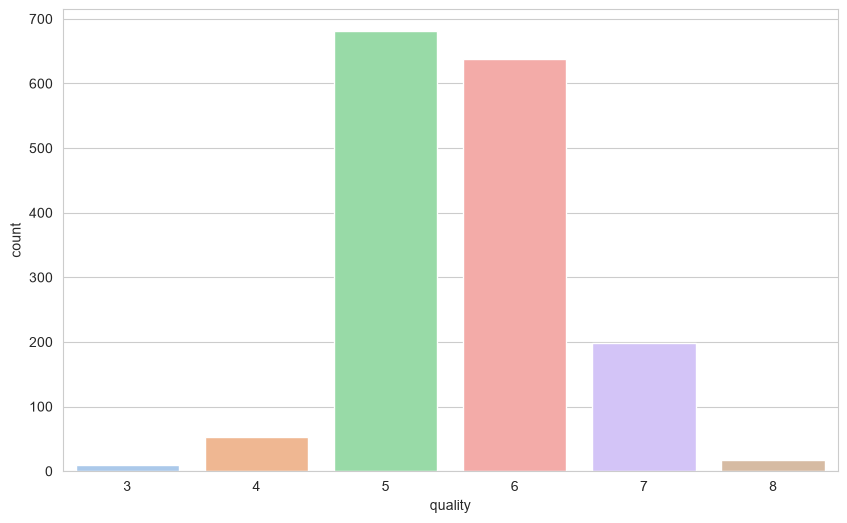

In [45]:
# visualization 
sns.set_style(style='whitegrid')
print(wdf['quality'].value_counts())
fig=plt.figure(figsize=(10,6))
sns.countplot(data=wdf,x='quality',palette='pastel')
plt.show()

In [46]:
num_cols=wdf.select_dtypes(include='number')
num_cols

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5
1,7.8,0.880,0.00,2.6,0.098,25.0,67.0,0.99680,3.20,0.68,9.8,5
2,7.8,0.760,0.04,2.3,0.092,15.0,54.0,0.99700,3.26,0.65,9.8,5
3,11.2,0.280,0.56,1.9,0.075,17.0,60.0,0.99800,3.16,0.58,9.8,6
4,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5
...,...,...,...,...,...,...,...,...,...,...,...,...
1594,6.2,0.600,0.08,2.0,0.090,32.0,44.0,0.99490,3.45,0.58,10.5,5
1595,5.9,0.550,0.10,2.2,0.062,39.0,51.0,0.99512,3.52,0.76,11.2,6
1596,6.3,0.510,0.13,2.3,0.076,29.0,40.0,0.99574,3.42,0.75,11.0,6
1597,5.9,0.645,0.12,2.0,0.075,32.0,44.0,0.99547,3.57,0.71,10.2,5


<Axes: >

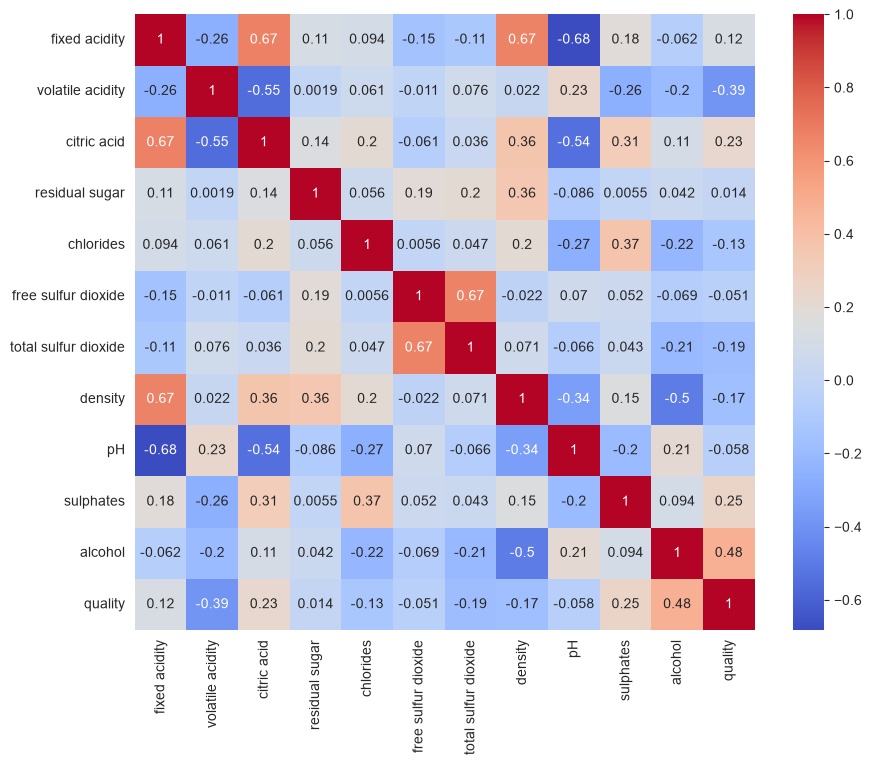

In [48]:
plt.figure(figsize=(10,8))
sns.heatmap(num_cols.corr(), annot=True, cmap='coolwarm')

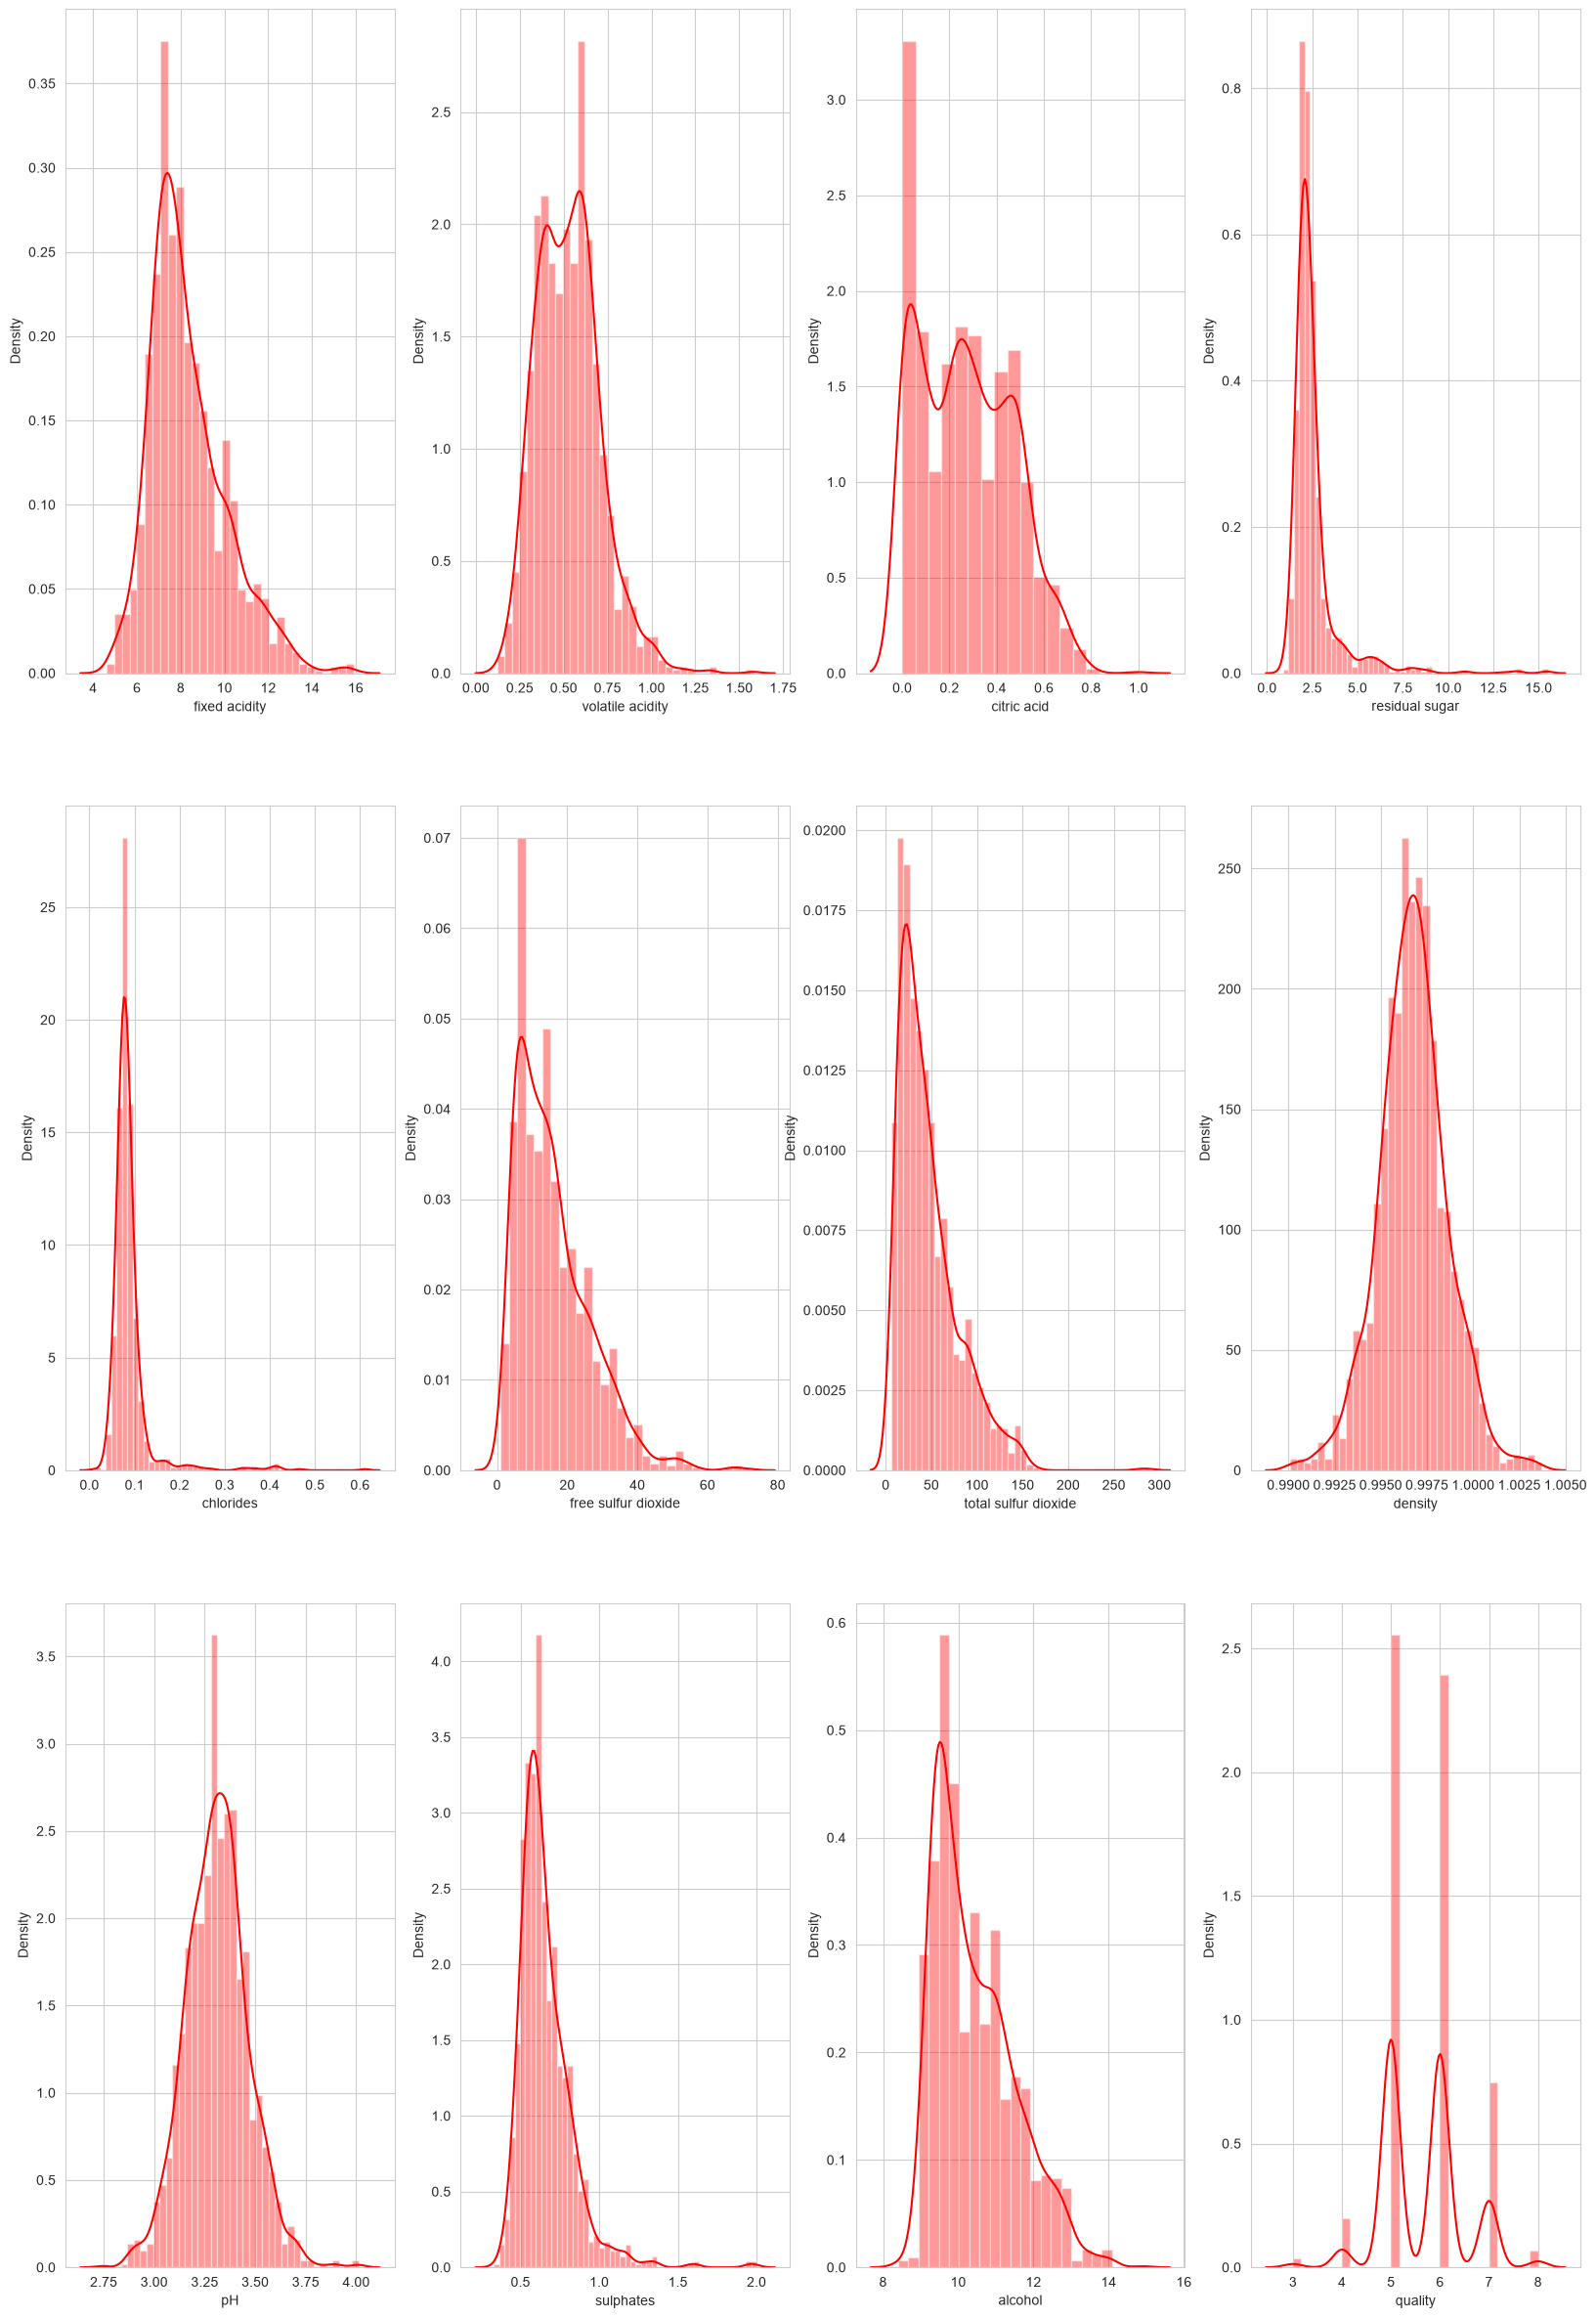

In [49]:
color = sns.color_palette('pastel')

fig,ax1 = plt.subplots(3,4,figsize=(20,30))
k=0
columns=list(wdf.columns)
for i in range(3):
    for j in range(4):
        sns.distplot(wdf[columns[k]],ax=ax1[i][j],color='red')
        k=k+1
plt.show()

In [52]:
# log transformation
def log_transformation(col):
    return np.log(col[0])

In [53]:
wdf['residual sugar']=wdf[['residual sugar']].apply(log_transformation,axis=1)
wdf['chlorides']=wdf[['chlorides']].apply(log_transformation,axis=1)
wdf['free sulfur dioxide']=wdf[['free sulfur dioxide']].apply(log_transformation,axis=1)
wdf['total sulfur dioxide']=wdf[['total sulfur dioxide']].apply(log_transformation,axis=1)
wdf['sulphates']=wdf[['sulphates']].apply(log_transformation,axis=1)

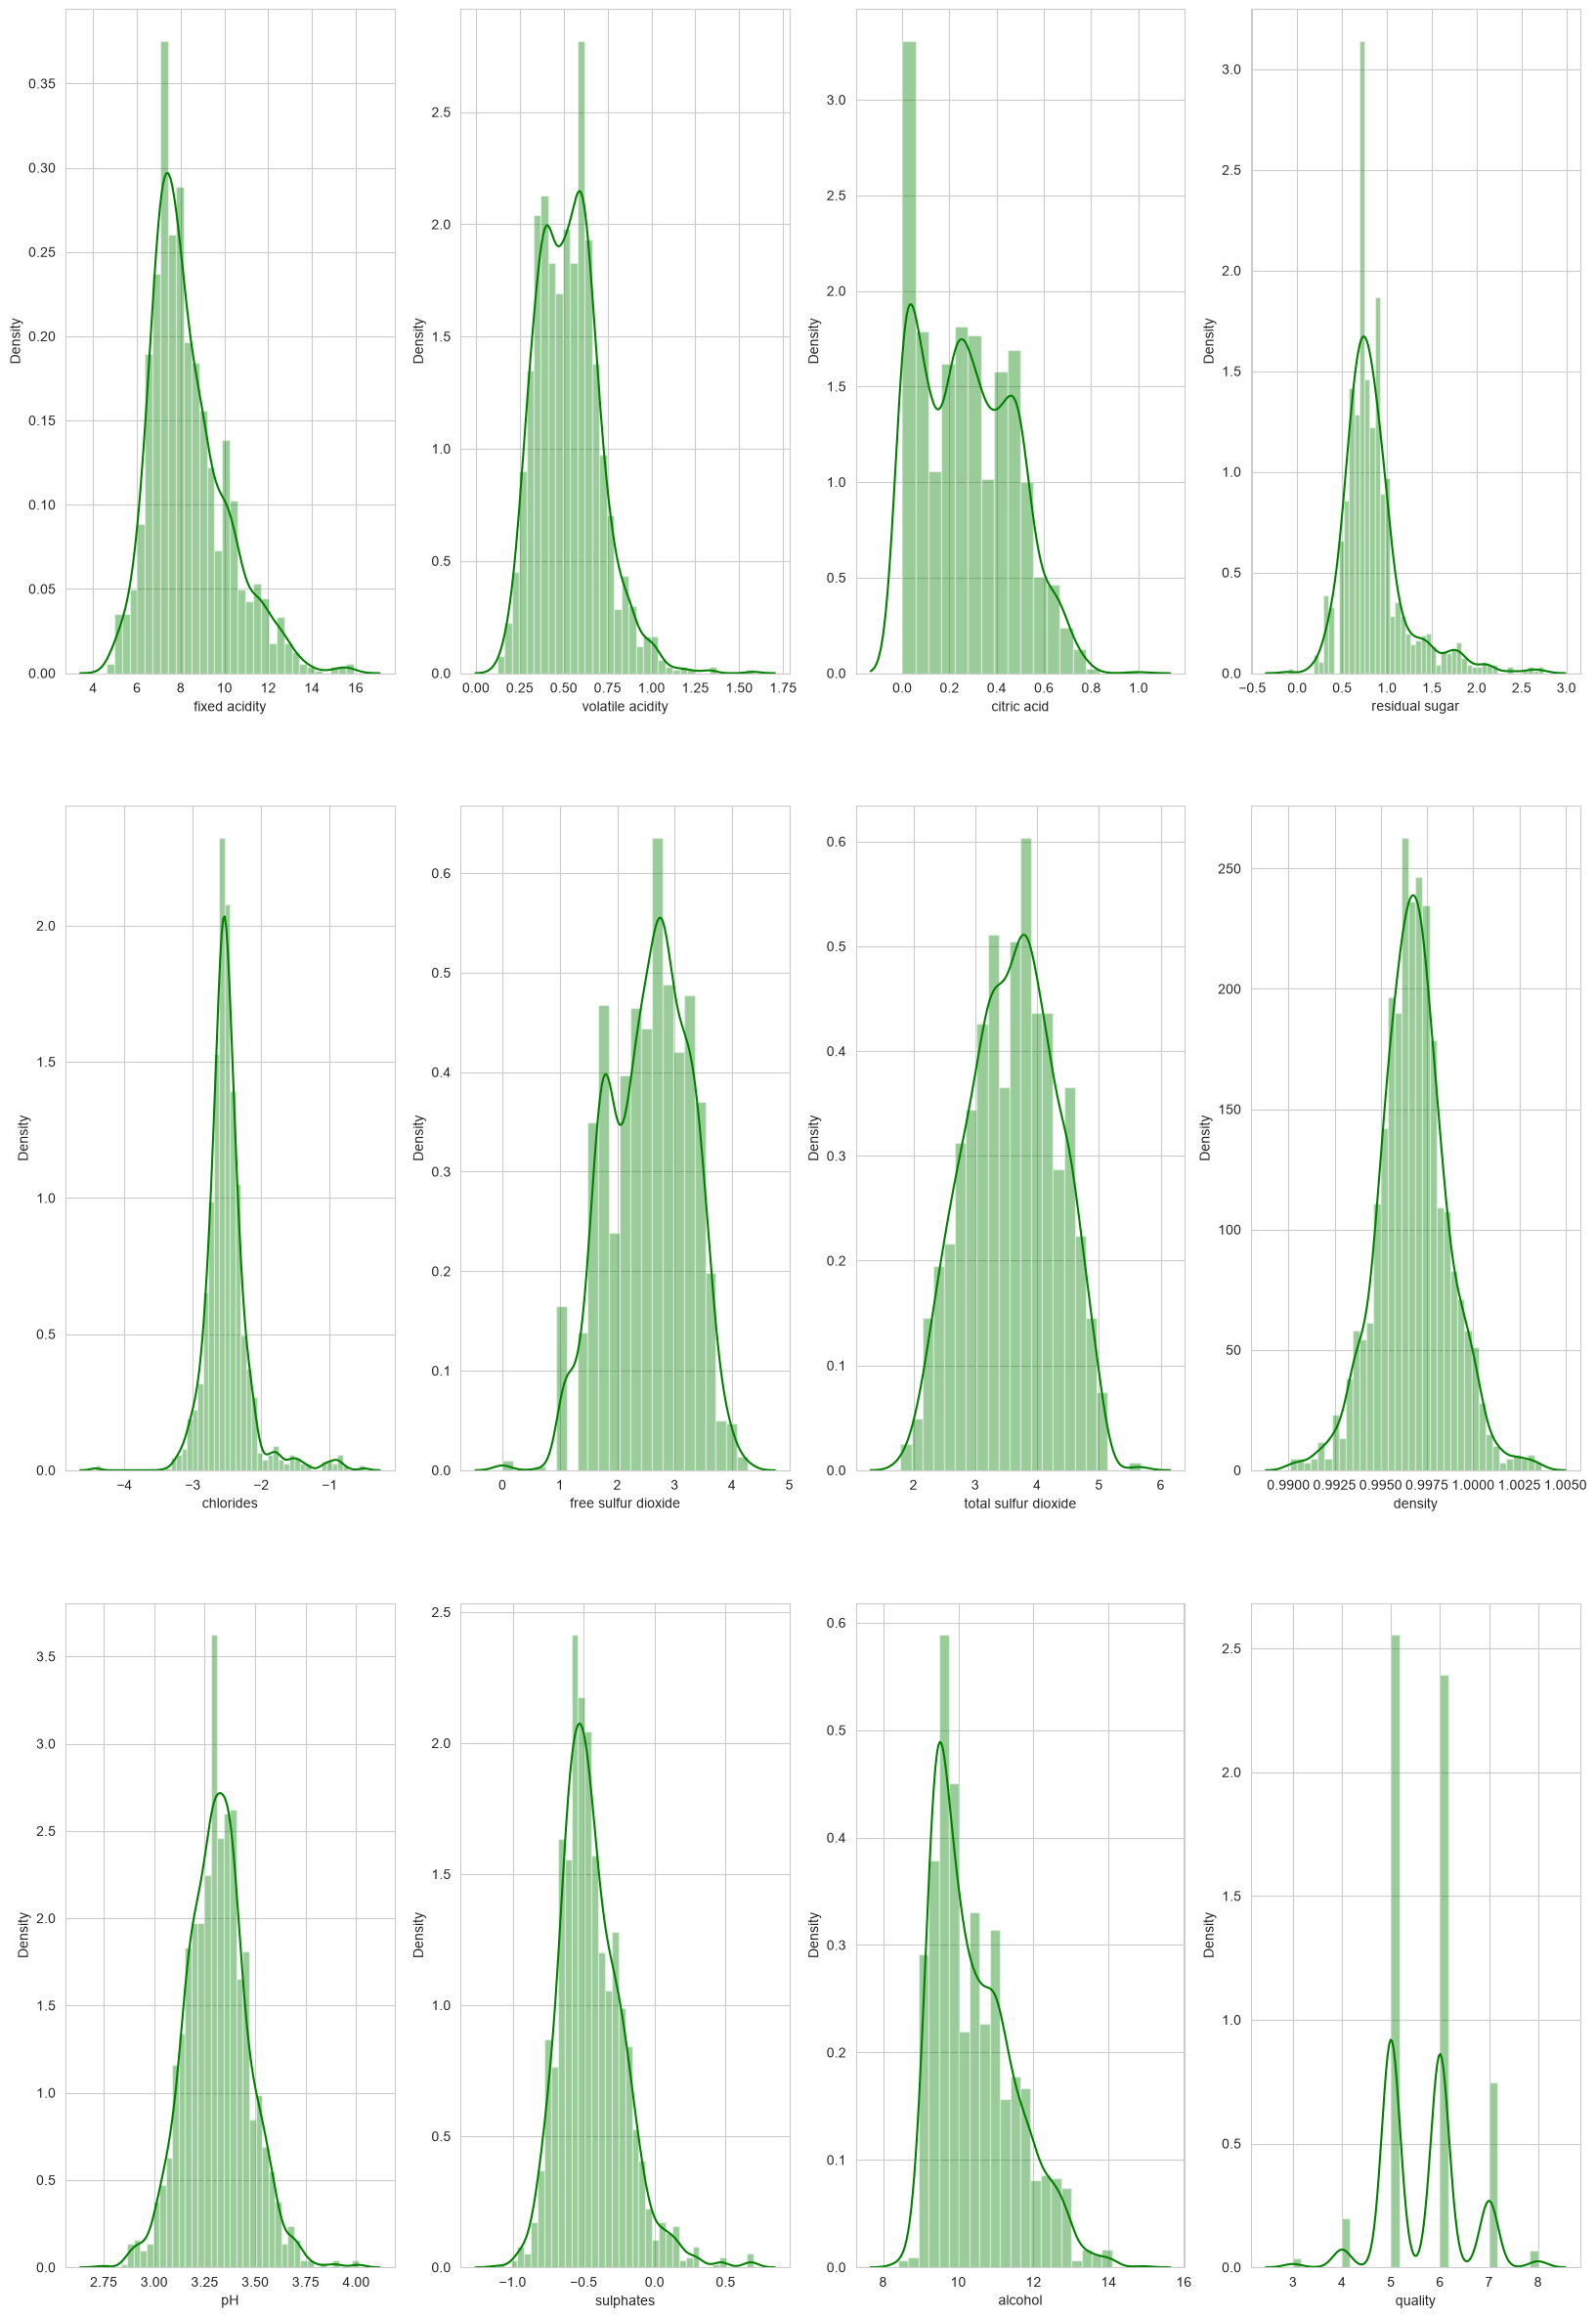

In [54]:
color = sns.color_palette('pastel')

fig,ax1 = plt.subplots(3,4,figsize=(20,30))
k=0
columns=list(wdf.columns)
for i in range(3):
    for j in range(4):
        sns.distplot(wdf[columns[k]],ax=ax1[i][j],color='green')
        k=k+1
plt.show()

In [55]:
wdf.corr()['quality'].sort_values(ascending=False)

quality                 1.000000
alcohol                 0.476166
sulphates               0.308642
citric acid             0.226373
fixed acidity           0.124052
residual sugar          0.023533
free sulfur dioxide    -0.050087
pH                     -0.057731
total sulfur dioxide   -0.170143
density                -0.174919
chlorides              -0.176140
volatile acidity       -0.390558
Name: quality, dtype: float64

In [57]:
# dataset split
x = wdf.drop(columns=['quality']) # x is a independent variable
Y = wdf['quality'] # Y is a dependent variable

In [58]:
Y.value_counts()

quality
5    681
6    638
7    199
4     53
8     18
3     10
Name: count, dtype: int64

In [59]:
pip install imblearn


   ---------------------------------------- 0/3 [sklearn-compat]
   ---------------------------------------- 0/3 [sklearn-compat]
   ---------------------------------------- 0/3 [sklearn-compat]
   ------------- -------------------------- 1/3 [imbalanced-learn]
   ------------- -------------------------- 1/3 [imbalanced-learn]
   ------------- -------------------------- 1/3 [imbalanced-learn]
   ------------- -------------------------- 1/3 [imbalanced-learn]
   ------------- -------------------------- 1/3 [imbalanced-learn]
   ------------- -------------------------- 1/3 [imbalanced-learn]
   ------------- -------------------------- 1/3 [imbalanced-learn]
   ------------- -------------------------- 1/3 [imbalanced-learn]
   ------------- -------------------------- 1/3 [imbalanced-learn]
   ------------- -------------------------- 1/3 [imbalanced-learn]
   ------------- -------------------------- 1/3 [imbalanced-learn]
   ------------- -------------------------- 1/3 [imbalanced-learn]


In [62]:
#Oversampling
from imblearn.over_sampling import SMOTE
oversample = SMOTE(k_neighbors=4)
x,Y=oversample.fit_resample(x.fillna(0),Y)

In [61]:
Y.value_counts()

quality
5    681
6    681
7    681
4    681
8    681
3    681
Name: count, dtype: int64

In [ ]:
# oversampling is a technique in which we bring the minority count equal to majority count 
# undersampling is a technique in which we bring the majority count equal to minority count 

In [63]:
from sklearn.model_selection import train_test_split , cross_val_score

In [64]:
def classify(model, x, Y):
    x_train,x_test,Y_train,Y_test=train_test_split(x,Y,test_size=0.2,random_state=9)
    model.fit(x_train,Y_train)
    return model.score(x_test, Y_test)*100

In [65]:
# Apply logistic regression
from sklearn.linear_model import LogisticRegression
model = LogisticRegression()
LR_acc = classify(model,x,Y)
LR_acc

54.400977995110026

In [ ]:
# apply RFC
from sklearn.ensemble import RandomForestClassifier
model_rf = RandomForestClassifier()
rf_acc = classify(model_rf,x,Y)
rf_
